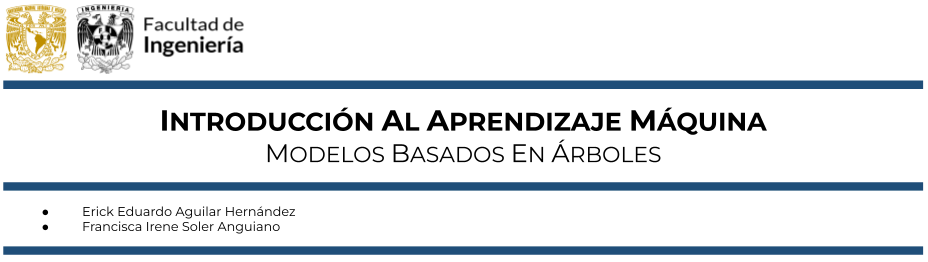

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 2.2 — Implementación: Ajuste de un árbol de regresión
___

### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para reproducir el ejemplo computacional del capítulo. 
Se cargan herramientas para manipulación de datos, visualización, métricas de regresión y manejo de rutas locales. 
Además, se fija el estilo gráfico `ggplot`, de modo que las visualizaciones del árbol mantengan una presentación homogénea a lo largo del notebook.


In [1]:
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import explained_variance_score as expv
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

### Carga y preparación del conjunto Auto MPG

Se carga el conjunto de datos **Auto MPG**, utilizado en el libro para ilustrar árboles de regresión. 
La variable respuesta es `mpg`, que mide el rendimiento del vehículo en millas por galón; las covariables seleccionadas describen características técnicas como cilindros, desplazamiento, potencia, peso, aceleración y año del modelo. 
Después de eliminar observaciones incompletas, se separa la matriz de predictores `X` del vector objetivo `y`, dejando los datos listos para ajustar el árbol.


In [ ]:
data_paths = [Path("datos") / "mpg.csv", Path("..") / "datos" / "mpg.csv"]
data_path = next(path for path in data_paths if path.exists())
mpg_df = pd.read_csv(data_path).dropna()

features = ["cylinders", "displacement", "horsepower",
            "weight", "acceleration", "model_year"]

display(mpg_df)

X = mpg_df[features]
y = mpg_df["mpg"]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


### Expansión de un árbol sin restricción

El siguiente código produce el siguiente arbol de regresión ajustado al conjunto de datos Auto MPG sin restricciones de profundidad. La gran cantidad de nodos y particiones refleja la alta complejidad del modelo y evidencia el riesgo de sobreajuste (concepto que veremos más adelante) cuando no se controla la profundidad del árbol.

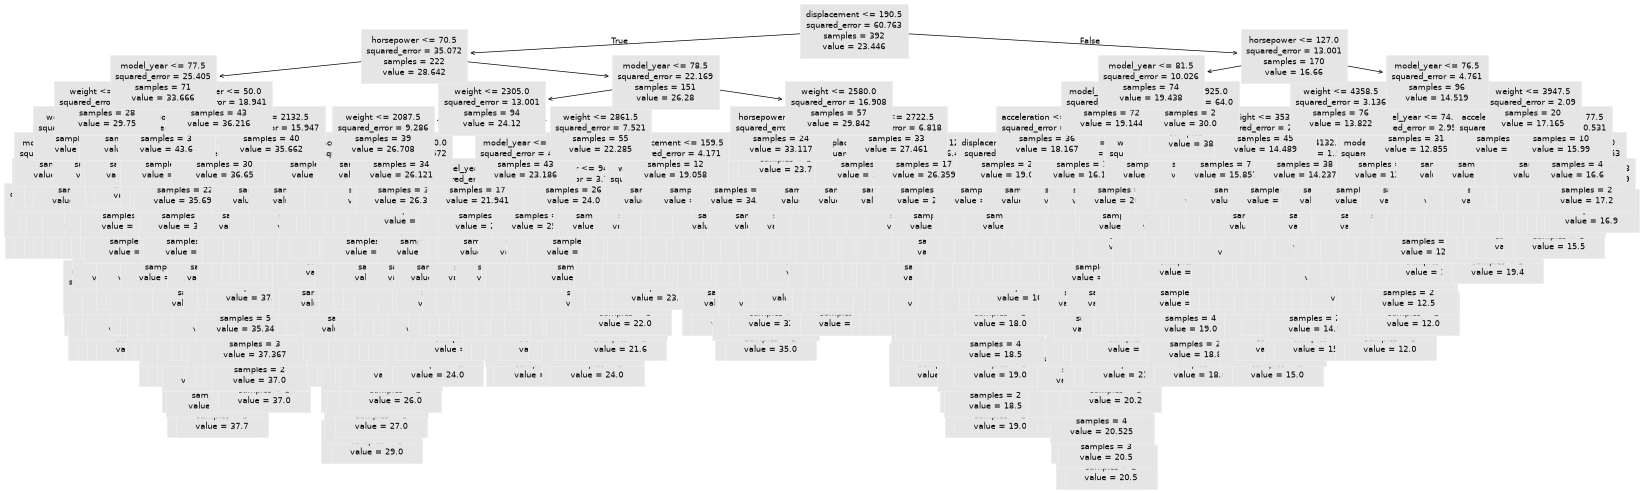

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

tree_regressor_1 = DecisionTreeRegressor(random_state=42)
tree_regressor_1.fit(X, y)

plt.figure(figsize=(20,6))
ars = plot_tree(tree_regressor_1,feature_names=features, fontsize=6)

### Expansión de un árbol con criterios de pre-poda
El segundo código de ajuste produce un árbol de regresión con restricciones de complejidad **max_depth=4** y **min_samples_leaf=10**. A diferencia del árbol sin restricciones, este modelo presenta una estructura más compacta y menos particiones, lo que reduce la varianza y mejora la capacidad de generalización. La limitación en la profundidad y el tamaño mínimo de las hojas actúa como un mecanismo de pre-poda.

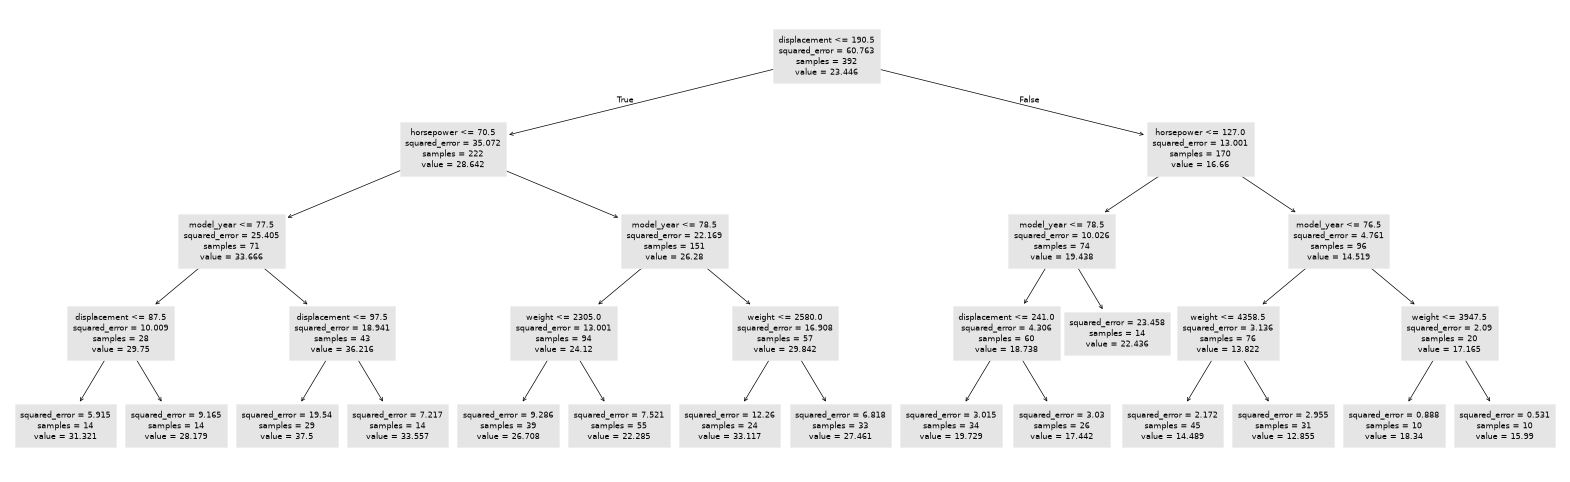

In [4]:
max_depth = 4
min_samples_leaf = 10
tree_regressor_2 = DecisionTreeRegressor(
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf)\
                        .fit(X,y)

plt.figure(figsize=(20,6))
ars = plot_tree(tree_regressor_2, feature_names=features, fontsize=6)

___
#### Notebook 2.4 — Implementación: Importancia de variables en árboles de regresión
___

### Importancia de las variables de un árbo de regresión

Importancia relativa de las variables en el árbol de regresión ajustado al conjunto Auto MPG. Se observa que **displacement,(desplazamiento del motor)** es la variable con mayor contribución explicativa, seguida por **horsepower** y **model\_year**. En contraste, **cylinder** y **acceleration** no contribuyen a las particiones del modelo bajo la configuración con pre-poda.

,variable,importance
1,displacement,0.674373
2,horsepower,0.174171
5,model_year,0.10524
3,weight,0.046216
0,cylinders,0.0
4,acceleration,0.0


<Axes: xlabel='importance', ylabel='variable'>

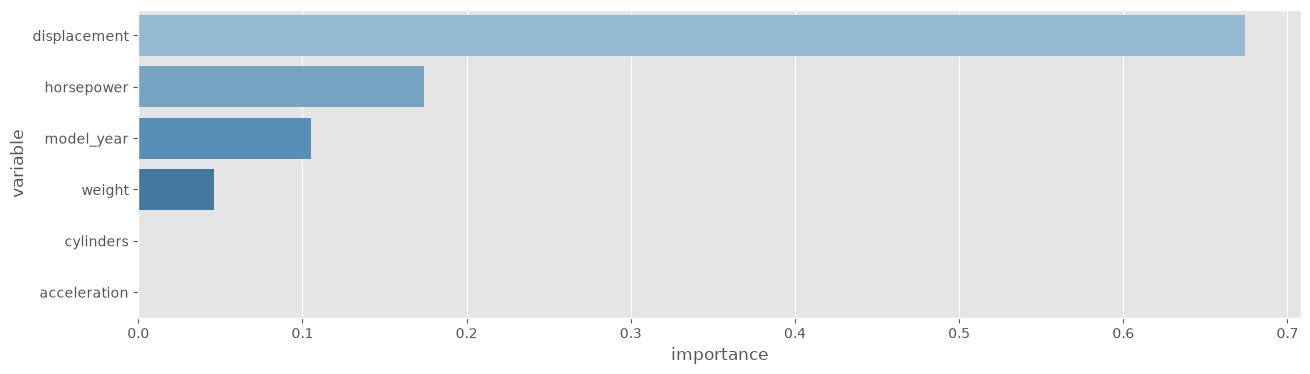

In [9]:
importances_df = pd.DataFrame([features,
                               tree_regressor_2.feature_importances_])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)

display(importances_df)
plt.figure(figsize=(15,4))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")